In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.shape)

print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
le = LabelEncoder()

df['sentiment'] = le.fit_transform(df['sentiment'])

In [5]:
x = df['review'].values

y = df['sentiment'].values

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

In [7]:
vocab_size = 10000

max_len = 200

In [8]:
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(x_train)

In [9]:
x_train_seq = tokenizer.texts_to_sequences(x_train)

x_test_seq = tokenizer.texts_to_sequences(x_test)

In [10]:
x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [11]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=max_len
    )
)

model.add(GlobalAveragePooling1D())

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

C:\Users\soham\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 961,637 (3.67 MB)

 Trainable params: 320,545 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 641,092 (2.45 MB)

In [14]:
history = model.fit(
    x_train_pad,
    y_train,
    epochs= 5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7423 - loss: 0.5286 - val_accuracy: 0.8554 - val_loss: 0.3548
Epoch 2/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8668 - loss: 0.3471 - val_accuracy: 0.8749 - val_loss: 0.3054
Epoch 3/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8943 - loss: 0.2875 - val_accuracy: 0.8349 - val_loss: 0.3696
Epoch 4/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9104 - loss: 0.2546 - val_accuracy: 0.8754 - val_loss: 0.3139
Epoch 5/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9176 - loss: 0.2379 - val_accuracy: 0.8786 - val_loss: 0.3133


In [15]:
loss, accuracy = model.evaluate(
    x_test_pad,
    y_test
)

print("Accuracy:", accuracy)

print("Loss:", loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8773 - loss: 0.3127
Accuracy: 0.8772666454315186
Loss: 0.312748521566391


In [16]:
y_pred_prob = model.predict(x_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6472  939]
 [ 902 6687]]


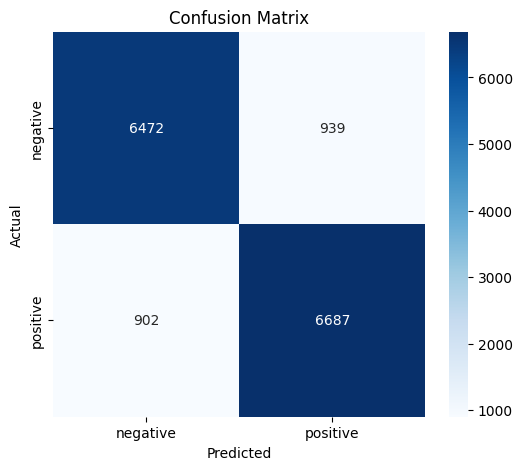

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['negative', 'positive']
))

              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      7411
    positive       0.88      0.88      0.88      7589

    accuracy                           0.88     15000
   macro avg       0.88      0.88      0.88     15000
weighted avg       0.88      0.88      0.88     15000



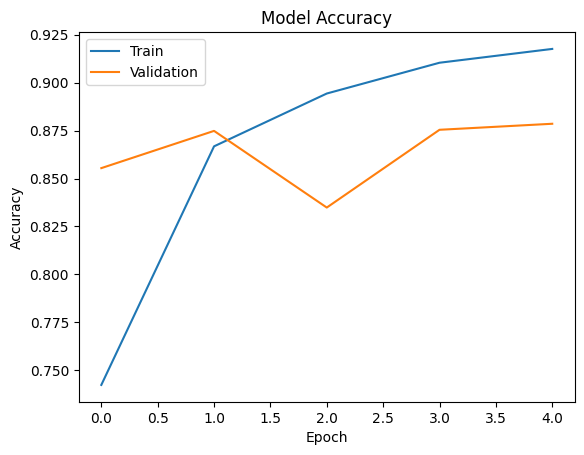

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

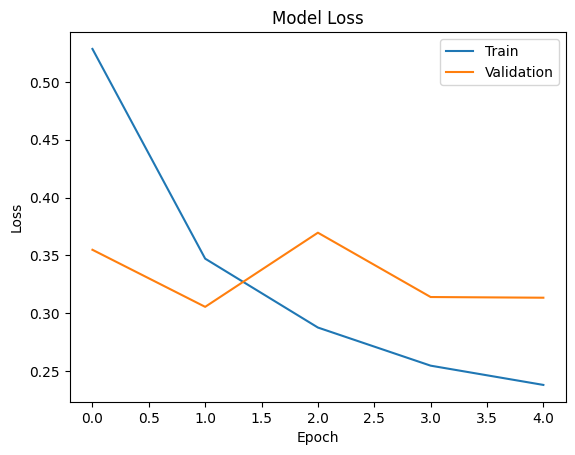

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()